In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import jax.numpy as jnp
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Ensure your custom class is in the same directory or installed
from bilinear_lasso import bilinear_lasso

# --- Configuration ---
DATA_DIR = "/Users/xue6bq/Desktop/Aiying/Data"
OUTPUT_DIR = "cv_results_parallel"
P, N_SUBJECTS = 264, 787
LAMBDA_GRID = [2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3, 3.1, 3.2]
N_SPLITS, N_JOBS = 5, 4
MAX_ITER, STEP_SIZE, TOL = 2000, 1e-6, 1e-5

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_fmri_data(data_dir, p=264, n_subjects=None):
    z_rs = np.load(os.path.join(data_dir, "z_rs_raw.npy")).reshape((-1, p, p))
    z_emo = np.load(os.path.join(data_dir, "z_emo_raw.npy")).reshape((-1, p, p))
    y = np.load(os.path.join(data_dir, "y.npy"))
    
    # Transpose to p x p x n (nodes, nodes, subjects)
    X1 = jnp.array(np.transpose(z_rs, (1, 2, 0)))
    X2 = jnp.array(np.transpose(z_emo, (1, 2, 0)))
    y = jnp.array(y)
    
    print(f"Loaded Data: X1={X1.shape}, X2={X2.shape}, y={y.shape}")
    return X1, X2, y

def predict_bilinear(X1, X2, beta1, beta2):
    """Computes b.T * X * b across all subjects."""
    b1 = np.array(beta1).flatten()
    b2 = np.array(beta2).flatten()
    X1_np, X2_np = np.array(X1), np.array(X2)
    
    return (np.einsum("i,ijk,j->k", b1, X1_np, b1) + 
            np.einsum("i,ijk,j->k", b2, X2_np, b2))

def evaluate_prediction(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    var_y = np.var(y_true)
    r2 = 1 - mse / var_y if var_y > 1e-9 else np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1] if np.std(y_pred) > 1e-9 else 0
    return {"mse": float(mse), "r2": float(r2), "corr": float(corr)}

In [2]:
def calculate_ebic(mse, n_features, n_samples, total_p, gamma=0.5):
    """
    Computes BIC and EBIC.
    BIC = n*log(MSE) + k*log(n)
    EBIC = BIC + 2*gamma*k*log(p)
    """
    if mse <= 1e-12:  # Prevent log(0)
        return -np.inf, -np.inf
    
    k = n_features
    n = n_samples
    
    bic = n * np.log(mse) + k * np.log(n)
    # EBIC adds a penalty for the search space size (total_p)
    ebic = bic + 2 * gamma * k * np.log(total_p)
    
    return bic, ebic

def run_one_cv_fold(X1, X2, y, train_idx, val_idx, lam, p, max_iter, step_size, tol):
    # 1. Split Data
    X1_tr, X1_val = X1[:, :, train_idx], X1[:, :, val_idx]
    X2_tr, X2_val = X2[:, :, train_idx], X2[:, :, val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # 2. Centering (Subtract mean, maintain scale/STD)
    y_m = y_tr.mean()
    y_tr_c, y_val_c = y_tr - y_m, y_val - y_m
    
    X1_m, X2_m = X1_tr.mean(axis=2, keepdims=True), X2_tr.mean(axis=2, keepdims=True)
    X1_tr_c, X1_val_c = X1_tr - X1_m, X1_val - X1_m
    X2_tr_c, X2_val_c = X2_tr - X2_m, X2_val - X2_m

    # 3. Fit Model on Training Set
    model = bilinear_lasso(X1_tr_c, X2_tr_c, y_tr_c, lam, lam)
    model.initialize_beta(jnp.zeros((p, 1)), jnp.zeros((p, 1)))
    model.fit(num_candidates=1, max_iter=max_iter, step_size=step_size, tol=tol)

    # 4. Extract Support
    # Using a small epsilon to catch non-zero coefficients
    supp1 = np.where(np.abs(np.array(model.beta1).flatten()) > 0.1)[0]
    supp2 = np.where(np.abs(np.array(model.beta2).flatten()) > 0.1)[0]
    n_features = len(supp1) + len(supp2)

    # 5. Training Evaluation (For BIC/EBIC)
    y_pred_tr = predict_bilinear(X1_tr_c, X2_tr_c, model.beta1, model.beta2)
    tr_mse = np.mean((np.array(y_tr_c) - y_pred_tr)**2)
    
    # Calculate BIC and EBIC (p*2 because we have two beta vectors of size p)
    bic, ebic = calculate_ebic(tr_mse, n_features, len(train_idx), p * 2)

    # 6. Validation Evaluation (For Prediction Performance)
    y_pred_val = predict_bilinear(X1_val_c, X2_val_c, model.beta1, model.beta2)
    metrics = evaluate_prediction(y_val_c, y_pred_val)
    
    return {
        "lambda": lam,
        "val_mse": metrics["mse"],
        "val_r2": metrics["r2"],
        "val_corr": metrics["corr"],
        "tr_mse": float(tr_mse),
        "bic": float(bic),
        "ebic": float(ebic),
        "supp1": supp1,
        "supp2": supp2,
        "n_features": n_features
    }

def run_one_lambda_cv(lam, X1, X2, y):
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=2026)
    
    # Run the folds
    folds = [run_one_cv_fold(X1, X2, y, tr, val, lam, P, MAX_ITER, STEP_SIZE, TOL) 
             for tr, val in kf.split(np.arange(y.shape[0]))]
    
    # Metrics extraction
    mse_list = [f["val_mse"] for f in folds]
    mean_mse = np.mean(mse_list)
    sd_mse = np.std(mse_list)
    
    # Aggregating Information Criteria
    mean_bic = np.mean([f["bic"] for f in folds])
    mean_ebic = np.mean([f["ebic"] for f in folds])
    
    # Stability: Lower is more consistent across folds
    cv_stability = sd_mse / mean_mse if mean_mse > 1e-9 else np.nan
    
    return {
        "lambda": lam,
        "mean_r2": np.mean([f["val_r2"] for f in folds]),
        "mean_mse": mean_mse,
        "sd_mse": sd_mse,
        "mean_bic": mean_bic,
        "mean_ebic": mean_ebic,
        "cv_stability": cv_stability, 
        "mean_features": np.mean([f["n_features"] for f in folds]),
        "folds": folds
    }

In [3]:
X1, X2, y = load_fmri_data(DATA_DIR, P, N_SUBJECTS)

# 1. Run the parallel CV
results = Parallel(n_jobs=N_JOBS)(
    delayed(run_one_lambda_cv)(l, X1, X2, y) for l in LAMBDA_GRID
)

# 2. Organize into a comprehensive summary table
summary_data = []
for r in results:
    summary_data.append({
        "lambda": r["lambda"],
        "Test R2": r["mean_r2"],
        "Avg Features": r["mean_features"],
        "EBIC": r["mean_ebic"],        # Added for model selection
        "BIC": r["mean_bic"],          # Added for reference
        "Stability": r["cv_stability"], # Lower is more reliable
        "MSE Mean": r["mean_mse"]
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Sort by EBIC (often the most robust metric for fMRI feature selection)
summary_df = summary_df.sort_values("EBIC")

print("\n--- Model Evaluation Summary (Sorted by EBIC) ---")
display(summary_df)

Loaded Data: X1=(264, 264, 787), X2=(264, 264, 787), y=(787,)
0 th try
initialized loss: 398.5603332519531


  0%|          | 0/2000 [00:00<?, ?it/s]1.94it/s]

0 th try
initialized loss: 386.59783935546875


  0%|          | 0/2000 [00:00<?, ?it/s]9.48it/s]

0 th try
initialized loss: 395.6216125488281


...

  0%|          | 0/2000 [00:00<?, ?it/s]

Job took:  115.49982523918152
Final loss: 370.26104736328125
Final loss: 370.26104736328125
0 th try
initialized loss: 391.60870361328125


100%|██████████| 2000/2000 [01:55<00:00, 17.33it/s]


Job took:  115.43218779563904
Final loss: 364.5455627441406
Final loss: 364.5455627441406

--- Model Evaluation Summary (Sorted by EBIC) ---


,lambda,Test R2,Avg Features,EBIC,BIC,Stability,MSE Mean
8,3.2,0.050917,42.4,4155.634175,3889.824493,0.036052,370.681769
7,3.1,0.044659,42.6,4161.744888,3894.681386,0.065354,373.372699
5,2.9,0.058861,46.8,4210.037762,3916.644056,0.030034,367.457159
6,3.0,0.059306,48.2,4221.365875,3919.195435,0.022610,367.380841
4,2.8,0.024493,55.0,4310.950347,3966.150052,0.043651,380.558484
3,2.7,0.071442,63.0,4374.975851,3980.022785,0.081045,363.054590
1,2.5,0.033584,67.4,4429.412713,4006.875623,0.033936,377.257812
2,2.6,0.041124,70.2,4457.235078,4017.144519,0.048107,374.637756
0,2.4,0.057047,75.6,4528.204304,4054.260625,0.029612,368.266821


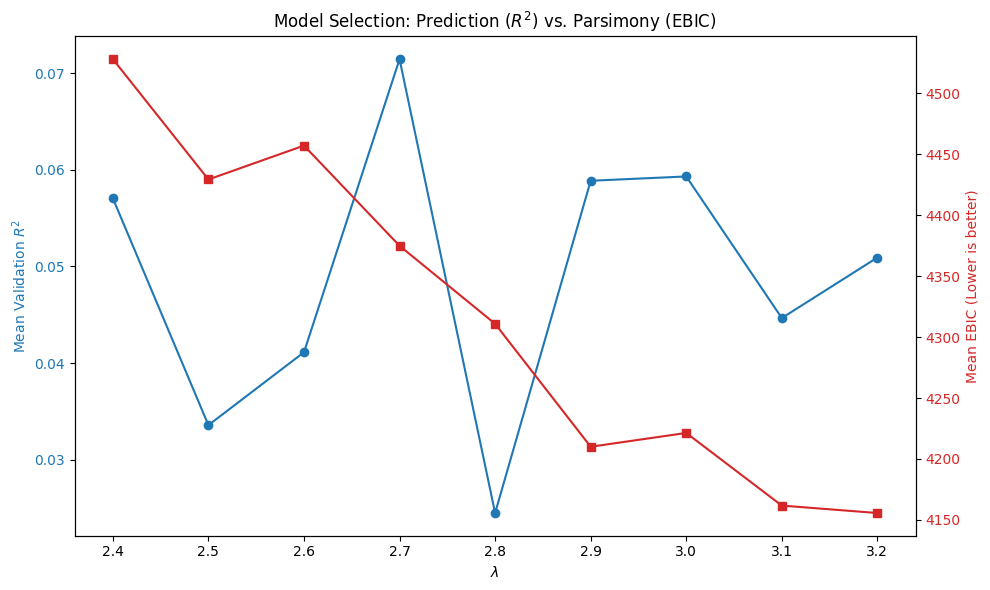

In [4]:
results_df = pd.DataFrame(results) # Assuming 'results' is the output of Parallel()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot R2 on the left axis
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("Mean Validation $R^2$", color="tab:blue")
ax1.plot(results_df["lambda"], results_df["mean_r2"], marker='o', color="tab:blue", label="$R^2$")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Plot EBIC on the right axis
ax2 = ax1.twinx()
ax2.set_ylabel("Mean EBIC (Lower is better)", color="tab:red")
ax2.plot(results_df["lambda"], results_df["mean_ebic"], marker='s', color="tab:red", label="EBIC")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("Model Selection: Prediction ($R^2$) vs. Parsimony (EBIC)")
fig.tight_layout()
plt.show()

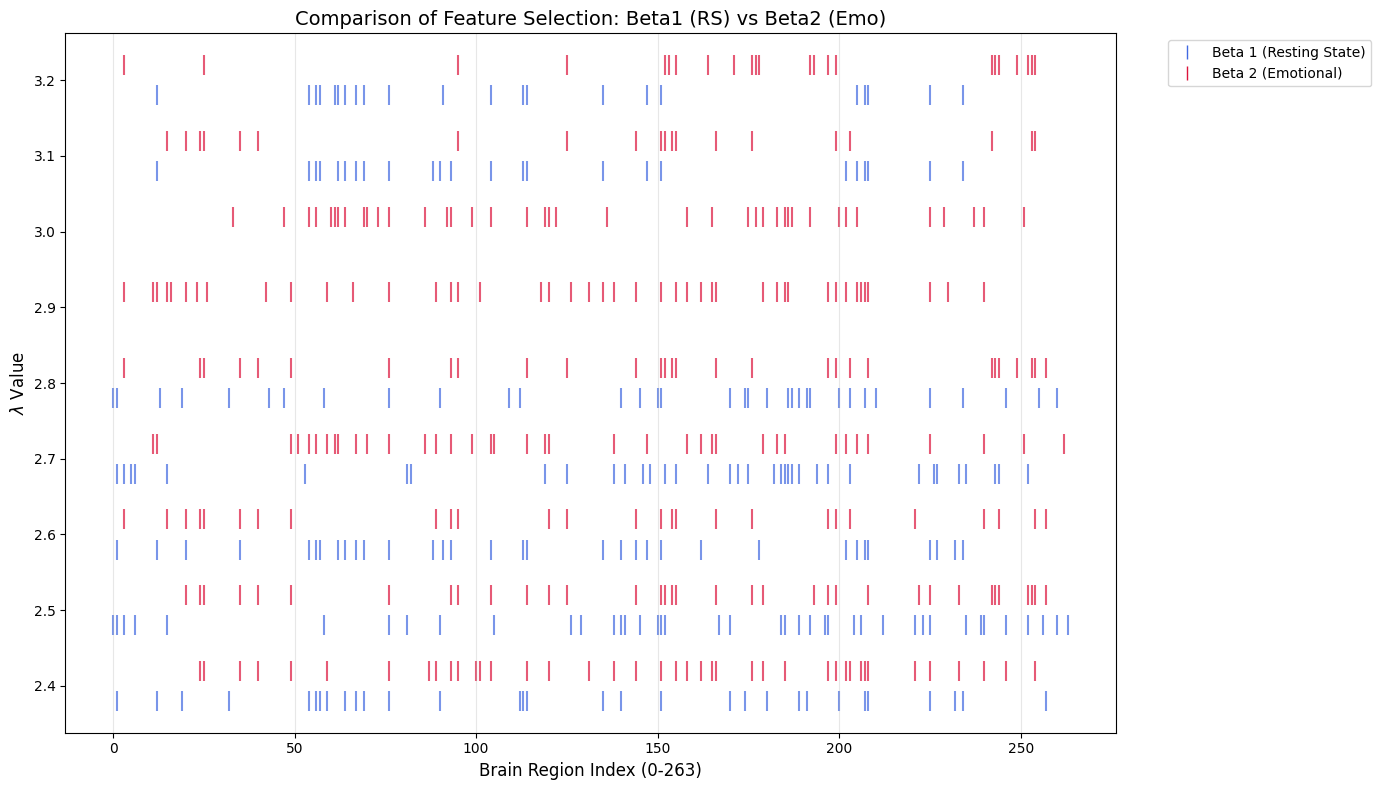

In [5]:
plt.figure(figsize=(14, 8))

for i, res in enumerate(results):
    lam = res["lambda"]
    # We'll take the first fold to represent the support for this lambda
    s1 = res["folds"][0]["supp1"]
    s2 = res["folds"][0]["supp2"]
    
    # Plot Beta 1 (Resting State)
    plt.scatter(s1, [lam - 0.02] * len(s1), color='royalblue', marker='|', 
                s=200, alpha=0.7, label=rf"$\beta_1$ (RS) for $\lambda$={lam}" if i == 0 else "")
    
    # Plot Beta 2 (Emotional) - Shifted slightly up so they don't overlap
    plt.scatter(s2, [lam + 0.02] * len(s2), color='crimson', marker='|', 
                s=200, alpha=0.7, label=rf"$\beta_2$ (Emo) for $\lambda$={lam}" if i == 0 else "")

plt.title("Comparison of Feature Selection: Beta1 (RS) vs Beta2 (Emo)", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)

# Custom legend to simplify the view
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='royalblue', marker='|', linestyle='None', markersize=10, label='Beta 1 (Resting State)'),
                   Line2D([0], [0], color='crimson', marker='|', linestyle='None', markersize=10, label='Beta 2 (Emotional)')]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

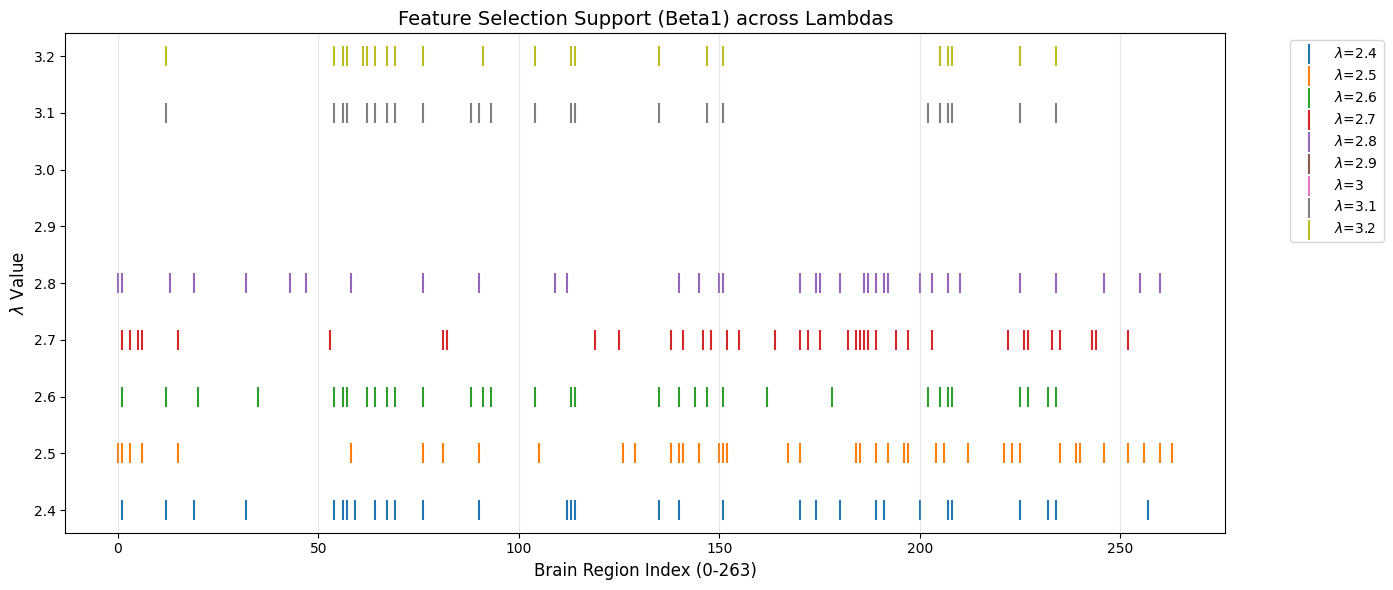

In [6]:
plt.figure(figsize=(14, 6))

for i, res in enumerate(results):
    # Taking support from the first fold of each lambda for comparison
    s1 = res["folds"][0]["supp1"]
    plt.scatter(s1, [res["lambda"]] * len(s1), marker='|', s=200, 
                label=rf"$\lambda$={res['lambda']}")

plt.title("Feature Selection Support (Beta1) across Lambdas", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)
plt.grid(True, axis='x', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

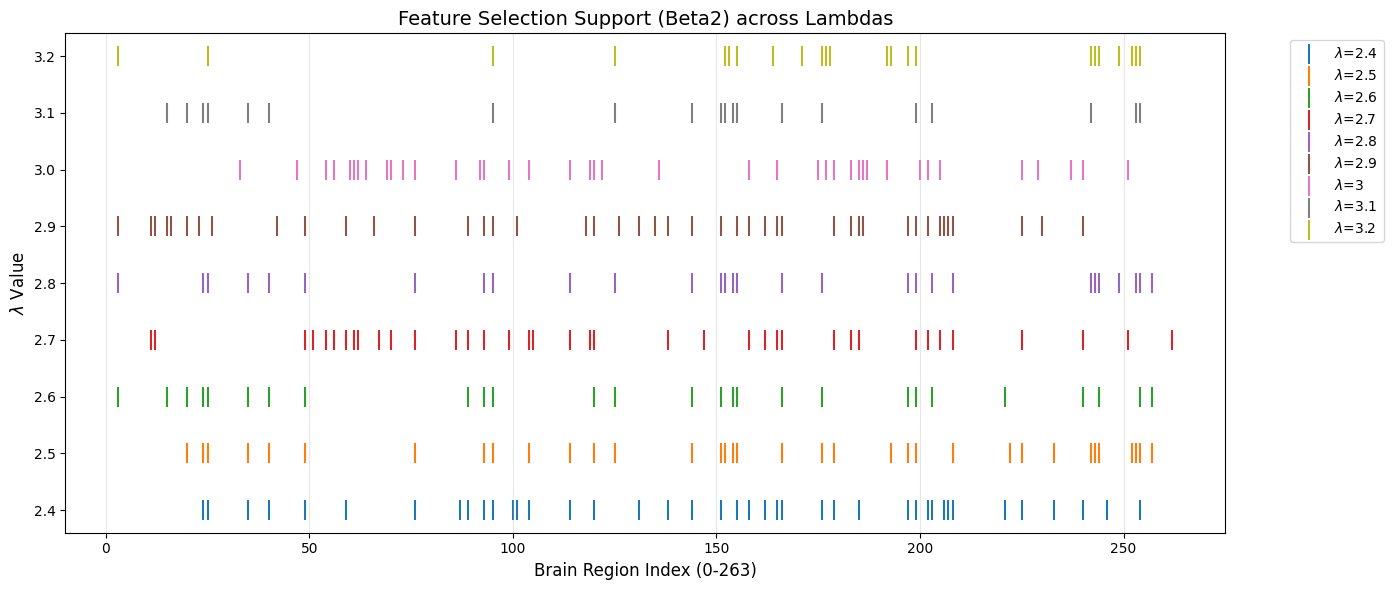

In [7]:
plt.figure(figsize=(14, 6))

for i, res in enumerate(results):
    # Taking support from the first fold of each lambda for comparison
    s1 = res["folds"][0]["supp2"]
    plt.scatter(s1, [res["lambda"]] * len(s1), marker='|', s=200, 
                label=rf"$\lambda$={res['lambda']}")

plt.title("Feature Selection Support (Beta2) across Lambdas", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)
plt.grid(True, axis='x', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
best_lam = float(summary_df.iloc[0]["lambda"])
print(f"Fitting final model with best lambda: {best_lam}")

# Center full data for final run
X1_c = X1 - X1.mean(axis=2, keepdims=True)
X2_c = X2 - X2.mean(axis=2, keepdims=True)
y_c = y - y.mean()

final_model = bilinear_lasso(X1_c, X2_c, y_c, best_lam, best_lam)
final_model.initialize_beta(jnp.zeros((P, 1)), jnp.zeros((P, 1)))
final_model.fit(num_candidates=3, max_iter=MAX_ITER, step_size=STEP_SIZE, tol=TOL)

# Final stats
final_y_pred = predict_bilinear(X1_c, X2_c, final_model.beta1, final_model.beta2)
final_metrics = evaluate_prediction(y_c, final_y_pred)


Fitting final model with best lambda: 3.2
0 th try
initialized loss: 391.11090087890625


100%|██████████| 2000/2000 [02:26<00:00, 13.67it/s]


Job took:  146.37433099746704
Final loss: 380.1218566894531
1 th try
initialized loss: 391.88970947265625


100%|██████████| 2000/2000 [35:10<00:00,  1.06s/it]    


Job took:  2110.2109277248383
Final loss: 376.176513671875
2 th try
initialized loss: 398.57403564453125


100%|██████████| 2000/2000 [49:12<00:00,  1.48s/it]    


Job took:  2952.859823703766
Final loss: 373.71148681640625
Final loss: 373.71148681640625


In [9]:
print(f"\nFinal Model R2 (Full Dataset): {final_metrics['r2']:.4f}")
print(f"Significant Features (Beta1): {len(np.where(np.abs(final_model.beta1) > 0.1)[0])}")


Final Model R2 (Full Dataset): 0.1465
Significant Features (Beta1): 0


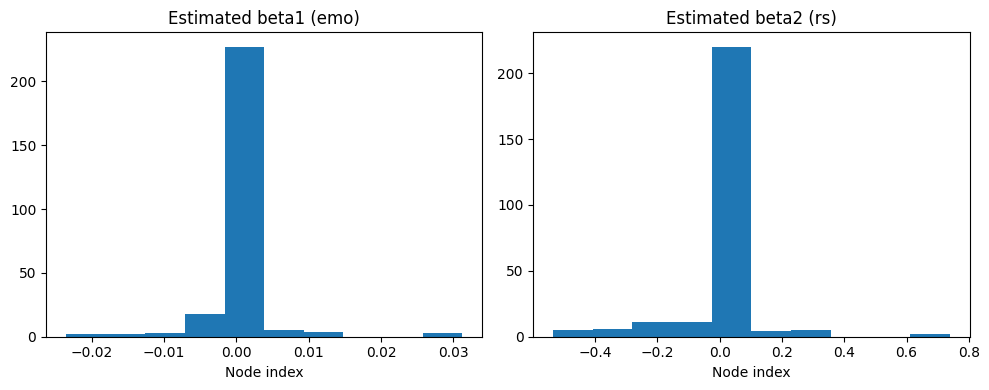

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# axs[0].bar(range(len(model.beta1)), np.array(model.beta1).flatten())
axs[0].hist(np.array(final_model.beta1).flatten())
axs[0].set_title('Estimated beta1 (emo)')
axs[0].set_xlabel('Node index')
# axs[1].bar(range(len(model.beta2)), np.array(model.beta2).flatten())
axs[1].hist(np.array(final_model.beta2).flatten())
axs[1].set_title('Estimated beta2 (rs)')
axs[1].set_xlabel('Node index')
plt.tight_layout()
plt.show()

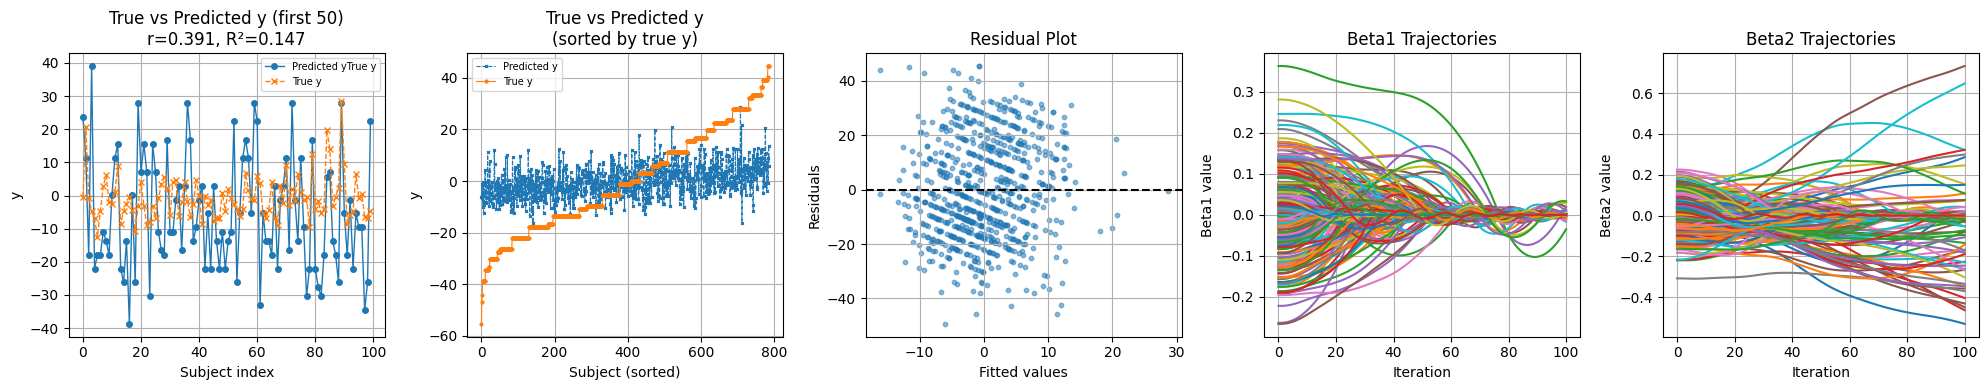

In [11]:
y_true = np.array(y_c)
y_hat = (np.einsum('ij,ijk,ji->k', final_model.beta1, np.array(X1_c), final_model.beta1) +
         np.einsum('ij,ijk,ji->k', final_model.beta2, np.array(X2_c), final_model.beta2))
residuals = y_true - y_hat

corr = np.corrcoef(y_true, y_hat)[0, 1]
r2   = 1 - np.var(residuals) / np.var(y_true)

beta1_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta1'])  # (num_steps, p, 1)
beta2_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta2'])  # (num_steps, p, 1)


plt.figure(figsize=(20, 4))

# Panel 1: First 50 subjects, line+dot style
plt.subplot(1, 5, 1)
plt.plot(y_true[:100], 'o-', markersize=4, linewidth=1, label='Predicted yTrue y')
plt.plot(y_hat[:100],  'x--', markersize=4, linewidth=1, label='True y')
plt.title(f'True vs Predicted y (first 50)\nr={corr:.3f}, R²={r2:.3f}')
plt.xlabel('Subject index')
plt.ylabel('y')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 2: Sorted by true y — predicted first (behind), true on top
plt.subplot(1, 5, 2)
idx = np.argsort(y_true)
plt.plot(y_hat[idx],  'x--', markersize=2, linewidth=0.8, label='Predicted y')
plt.plot(y_true[idx], 'o-',  markersize=2, linewidth=0.8, label='True y')
plt.title('True vs Predicted y\n(sorted by true y)')
plt.xlabel('Subject (sorted)')
plt.ylabel('y')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 3: Residual plot
plt.subplot(1, 5, 3)
plt.scatter(y_hat, residuals, s=10, alpha=0.5)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residual Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True)

# Panel 4: Beta1 trajectories (first 5 components)
plt.subplot(1, 5, 4)
for i in range(beta1_traj.shape[1]):
    plt.plot(beta1_traj[:, i, 0], label=f'beta1[{i}]')
plt.title('Beta1 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta1 value')
plt.grid(True)

# Panel 5: Beta2 trajectories (first 5 components)
plt.subplot(1, 5, 5)
for i in range(beta2_traj.shape[1]):
    plt.plot(beta2_traj[:, i], label=f'beta2[{i}]')
plt.title('Beta2 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta2 value')
plt.grid(True)

plt.tight_layout()
plt.show()

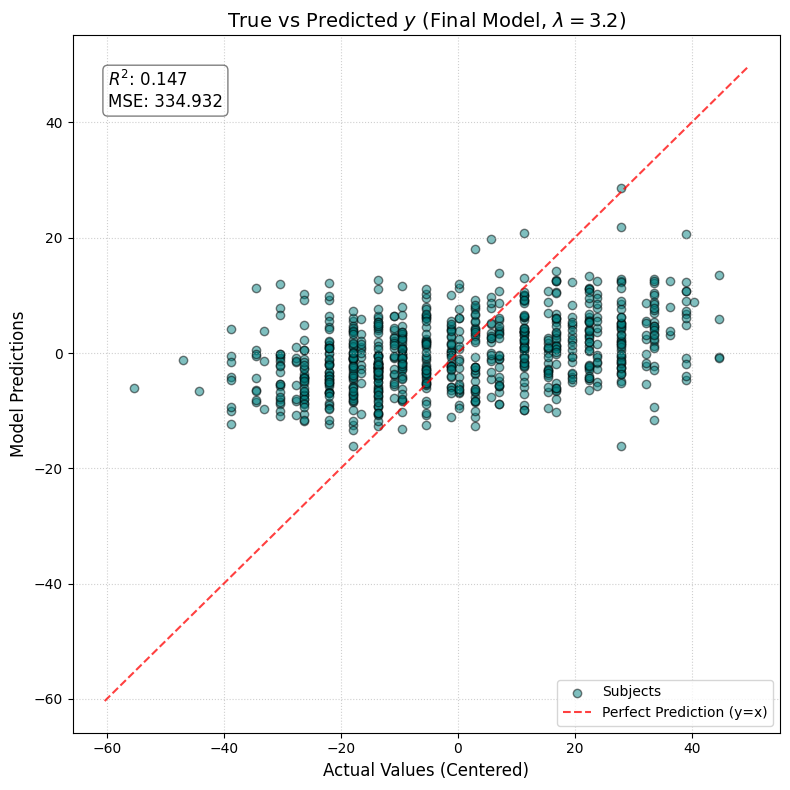

In [12]:
import matplotlib.pyplot as plt

def plot_regression_results(y_true, y_pred, lam_val):
    # Convert to numpy for plotting
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    plt.figure(figsize=(8, 8))
    
    # 1. Scatter plot of points
    plt.scatter(y_true_np, y_pred_np, alpha=0.5, color='teal', edgecolors='k', label='Subjects')
    
    # 2. Add the 45-degree "Perfect Prediction" line
    # We find the min/max of both axes to ensure the line covers the whole plot
    lims = [
        np.min([plt.xlim(), plt.ylim()]),  # min of both axes
        np.max([plt.xlim(), plt.ylim()]),  # max of both axes
    ]
    plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Perfect Prediction (y=x)')
    
    # 3. Formatting
    plt.title(rf"True vs Predicted $y$ (Final Model, $\lambda={lam_val}$)", fontsize=14)
    plt.xlabel("Actual Values (Centered)", fontsize=12)
    plt.ylabel("Model Predictions", fontsize=12)
    
    # Add a text box with metrics
    mse = np.mean((y_true_np - y_pred_np)**2)
    r2 = 1 - mse / np.var(y_true_np)
    stats_text = f"$R^2$: {r2:.3f}\nMSE: {mse:.3f}"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Execute the plot
# (Assuming final_y_pred and y_c come from your Final Model Fit cell)
plot_regression_results(y_c, final_y_pred, best_lam)

In [13]:
X1[:,:,0]

Array([[0.        , 1.1702881 , 0.7234536 , ..., 0.81617373, 0.66339827,
        0.5309873 ],
       [1.1702881 , 0.        , 0.5809368 , ..., 0.91559696, 0.6770624 ,
        0.49709845],
       [0.7234536 , 0.5809368 , 0.        , ..., 0.5272668 , 0.63788384,
        0.72128975],
       ...,
       [0.81617373, 0.91559696, 0.5272668 , ..., 0.        , 1.0475433 ,
        0.77799875],
       [0.66339827, 0.6770624 , 0.63788384, ..., 1.0475433 , 0.        ,
        0.94416934],
       [0.5309873 , 0.49709845, 0.72128975, ..., 0.77799875, 0.94416934,
        0.        ]], dtype=float32)